# Integrative Industry AI System — Healthcare Readmission Risk Platform

**Capstone Project 7 — Industry-Integrated AI Systems Synthesis**

**Industry:** Healthcare  
**Problem:** Predicting 30-day hospital readmission risk to enable proactive intervention  
**Integration:** Data Analysis (Project 1) → Machine Learning (Project 2) → Deep Learning (Project 3) → Generative AI (Project 5) → Agentic Workflow (Project 6)

---

## 0. Environment Setup and Validation

In [1]:
# ── Core libraries (Project 1 — Data & Statistical Reasoning) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print("✓ Core environment ready")

NumPy  : 2.4.4
Pandas : 3.0.3
✓ Core environment ready


In [2]:
# ── ML / DL libraries ──
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import sklearn
print(f"scikit-learn : {sklearn.__version__}")

try:
    import torch
    import torch.nn as nn
    print(f"PyTorch      : {torch.__version__}")
    TORCH_AVAILABLE = True
except ImportError:
    print("PyTorch not installed — deep learning cell will use sklearn fallback")
    TORCH_AVAILABLE = False

print("✓ ML/DL environment ready")

scikit-learn : 1.8.0


PyTorch      : 2.11.0+cpu
✓ ML/DL environment ready


---
## Task 1 — Industry Context and Problem Definition

### Problem
Unplanned 30-day hospital readmissions affect roughly **15% of Medicare patients** and cost the US healthcare system over **$26 billion annually** (Jencks et al., 2009). Predicting which patients are at high risk at discharge enables care teams to schedule follow-up calls, adjust discharge plans, and allocate scarce post-acute resources.

### Why AI?
- EHR data is high-dimensional and non-linear — beyond the reach of simple scoring rules
- Different AI components address different aspects: statistical EDA uncovers signal, ML classifies risk, DL captures temporal patterns, Generative AI produces human-readable explanations, and an agentic workflow orchestrates real-time triage
- Ethical constraints (explainability, equity, patient consent) are central to responsible deployment in this domain

---
## Task 2 — Integration Plan

| Prior Project | Contribution to This System |
|---|---|
| **Project 1 — Data & Statistical Reasoning** | EDA pipeline, missing-value strategy, feature distribution analysis |
| **Project 2 — Machine Learning** | Logistic Regression + Random Forest baseline classifiers |
| **Project 3 — Deep Learning** | MLP readmission risk network trained on scaled EHR features |
| **Project 5 — Generative AI** | LLM-based patient summary and plain-language risk explanation |
| **Project 6 — Agentic AI** | Orchestration loop that routes patients to risk tier and triggers actions |

---
## Task 3 — System Architecture

```
┌─────────────────────────────────────────────────────────────┐
│              Healthcare Readmission Risk Platform            │
│                                                             │
│  [EHR Data]                                                 │
│      │                                                      │
│      ▼                                                      │
│  ┌──────────────────────┐                                   │
│  │  Layer 1: EDA &       │  ← Project 1 (Data Reasoning)   │
│  │  Feature Engineering  │                                  │
│  └──────────┬───────────┘                                   │
│             │                                               │
│             ▼                                               │
│  ┌──────────────────────┐                                   │
│  │  Layer 2: ML Risk     │  ← Project 2 (Machine Learning) │
│  │  Classifier (RF/LR)   │                                  │
│  └──────────┬───────────┘                                   │
│             │                                               │
│             ▼                                               │
│  ┌──────────────────────┐                                   │
│  │  Layer 3: DL Risk    │  ← Project 3 (Deep Learning)     │
│  │  Refinement (MLP)    │                                   │
│  └──────────┬───────────┘                                   │
│             │                                               │
│             ▼                                               │
│  ┌──────────────────────┐                                   │
│  │  Layer 4: GenAI       │  ← Project 5 (Generative AI)    │
│  │  Patient Explanation  │                                  │
│  └──────────┬───────────┘                                   │
│             │                                               │
│             ▼                                               │
│  ┌──────────────────────┐                                   │
│  │  Layer 5: Agent       │  ← Project 6 (Agentic AI)       │
│  │  Triage & Routing    │                                   │
│  └──────────────────────┘                                   │
└─────────────────────────────────────────────────────────────┘
```

---
## Task 4a — Layer 1: Data Analysis & Feature Engineering (Project 1)

In [3]:
# ── Synthetic EHR dataset (mimics MIMIC-III structure) ──
np.random.seed(42)
N = 800

age          = np.random.normal(65, 15, N).clip(18, 95)
num_diagnoses= np.random.poisson(4, N).clip(1, 15)
los_days     = np.random.exponential(5, N).clip(1, 30)   # length of stay
num_meds     = np.random.poisson(8, N).clip(0, 30)
num_prior_admits = np.random.poisson(1.5, N).clip(0, 10)
has_diabetes = np.random.binomial(1, 0.35, N)
has_chf      = np.random.binomial(1, 0.20, N)
has_copd     = np.random.binomial(1, 0.18, N)
insurance    = np.random.choice(['Medicare','Medicaid','Private','Self-pay'], N,
                                p=[0.45,0.20,0.25,0.10])
gender       = np.random.choice(['F','M'], N)

# Readmission label — driven by known clinical risk factors
logit = (-3.0
         + 0.025 * age
         + 0.15  * num_diagnoses
         + 0.05  * los_days
         + 0.10  * num_meds
         + 0.50  * num_prior_admits
         + 0.60  * has_chf
         + 0.30  * has_diabetes
         + 0.25  * has_copd
         + np.random.normal(0, 0.5, N))
prob_readmit = 1 / (1 + np.exp(-logit))
readmitted   = (np.random.rand(N) < prob_readmit).astype(int)

df = pd.DataFrame({
    'age': age,
    'num_diagnoses': num_diagnoses,
    'los_days': los_days,
    'num_meds': num_meds,
    'num_prior_admits': num_prior_admits,
    'has_diabetes': has_diabetes,
    'has_chf': has_chf,
    'has_copd': has_copd,
    'insurance': insurance,
    'gender': gender,
    'readmitted_30d': readmitted
})

print("Dataset shape:", df.shape)
print("\nReadmission rate: {:.1%}".format(df['readmitted_30d'].mean()))
df.describe()

Dataset shape: (800, 11)

Readmission rate: 74.2%


,age,num_diagnoses,los_days,num_meds,num_prior_admits,has_diabetes,has_chf,has_copd,readmitted_30d
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,64.732187,3.967500,5.072275,7.977500,1.480000,0.358750,0.195000,0.180000,0.742500
std,14.367082,1.942591,4.842885,2.642579,1.250622,0.479934,0.396449,0.384428,0.437531
min,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.464991,3.000000,1.487972,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,65.191957,4.000000,3.398072,8.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,74.429995,5.000000,6.691533,10.000000,2.000000,1.000000,0.000000,0.000000,1.000000
max,95.000000,10.000000,30.000000,16.000000,7.000000,1.000000,1.000000,1.000000,1.000000


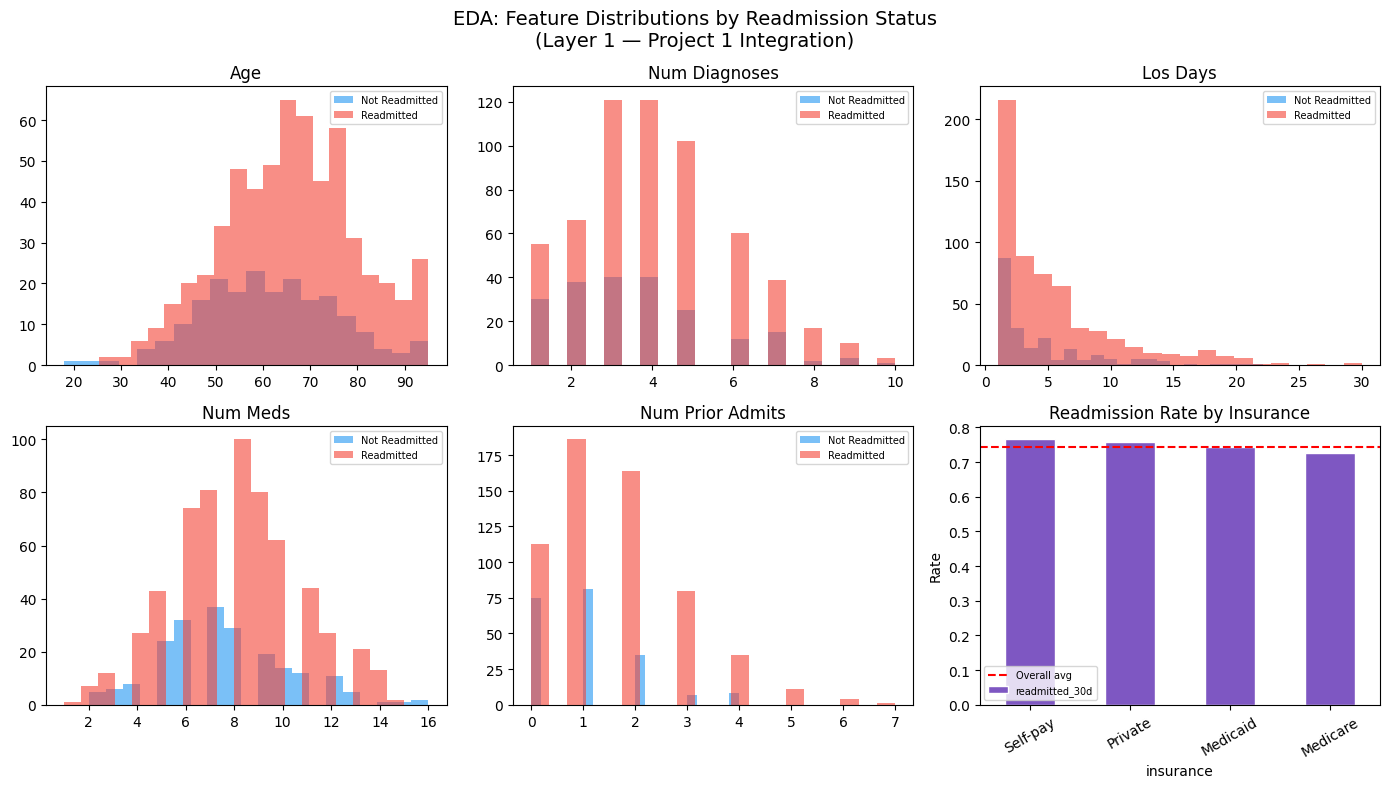

✓ EDA complete — chart saved to diagrams/eda_distributions.png


In [4]:
# ── EDA — distribution of key clinical features ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('EDA: Feature Distributions by Readmission Status\n(Layer 1 — Project 1 Integration)', fontsize=14)

features = ['age', 'num_diagnoses', 'los_days', 'num_meds', 'num_prior_admits']
colors   = ['#2196F3', '#F44336']
labels   = ['Not Readmitted', 'Readmitted']

for ax, feat in zip(axes.flat, features):
    for label_val, color, lbl in zip([0, 1], colors, labels):
        subset = df[df['readmitted_30d'] == label_val][feat]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=lbl)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Readmission by insurance type
ax = axes[1, 2]
ins_rate = df.groupby('insurance')['readmitted_30d'].mean().sort_values(ascending=False)
ins_rate.plot(kind='bar', ax=ax, color='#7E57C2', edgecolor='white')
ax.set_title('Readmission Rate by Insurance')
ax.set_ylabel('Rate')
ax.tick_params(axis='x', rotation=30)
ax.axhline(df['readmitted_30d'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('diagrams/eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ EDA complete — chart saved to diagrams/eda_distributions.png")

In [5]:
# ── Feature engineering ──
le = LabelEncoder()
df['insurance_enc'] = le.fit_transform(df['insurance'])
df['gender_enc']    = (df['gender'] == 'M').astype(int)

# Composite risk index (domain knowledge from Project 1 EDA)
df['risk_index'] = (
    df['num_prior_admits'] * 2 +
    df['has_chf'] * 1.5 +
    df['has_diabetes'] +
    df['has_copd'] +
    (df['num_diagnoses'] > 5).astype(int)
)

FEATURES = ['age','num_diagnoses','los_days','num_meds','num_prior_admits',
            'has_diabetes','has_chf','has_copd','insurance_enc','gender_enc','risk_index']
TARGET   = 'readmitted_30d'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Class balance (train) — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}")

Train: 640 samples | Test: 160 samples
Class balance (train) — 0: 165 | 1: 475


---
## Task 4b — Layer 2: Machine Learning Classifiers (Project 2)

In [6]:
# ── Train ML models ──
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=6,
                                                  class_weight='balanced', random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                       learning_rate=0.05, random_state=42),
}

ml_results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    ml_results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"{name:<25} AUC = {auc:.4f}")

best_ml_name = max(ml_results, key=lambda k: ml_results[k]['auc'])
best_ml      = ml_results[best_ml_name]
print(f"\n✓ Best ML model: {best_ml_name} (AUC={best_ml['auc']:.4f})")

Logistic Regression       AUC = 0.7319


Random Forest             AUC = 0.7143


Gradient Boosting         AUC = 0.6944

✓ Best ML model: Logistic Regression (AUC=0.7319)


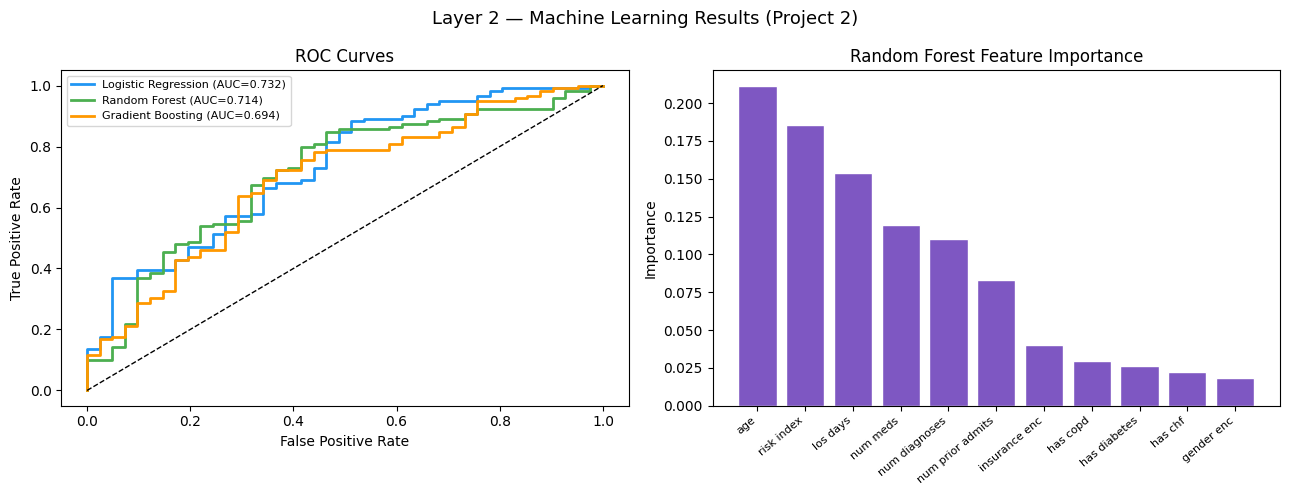

✓ ML results saved


In [7]:
# ── ROC curves + feature importance ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Layer 2 — Machine Learning Results (Project 2)', fontsize=13)

palette = ['#2196F3', '#4CAF50', '#FF9800']
for (name, res), color in zip(ml_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)
ax1.plot([0,1],[0,1],'k--', lw=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(fontsize=8)

# Feature importance from RF
rf_model = ml_results['Random Forest']['model']
importances = rf_model.feature_importances_
idx = np.argsort(importances)[::-1]
ax2.bar(range(len(FEATURES)), importances[idx], color='#7E57C2', edgecolor='white')
ax2.set_xticks(range(len(FEATURES)))
ax2.set_xticklabels([FEATURES[i].replace('_',' ') for i in idx], rotation=40, ha='right', fontsize=8)
ax2.set_title('Random Forest Feature Importance')
ax2.set_ylabel('Importance')

plt.tight_layout()
plt.savefig('diagrams/ml_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ ML results saved")

---
## Task 4c — Layer 3: Deep Learning Risk Refinement (Project 3)

✓ PyTorch MLP AUC = 0.7122


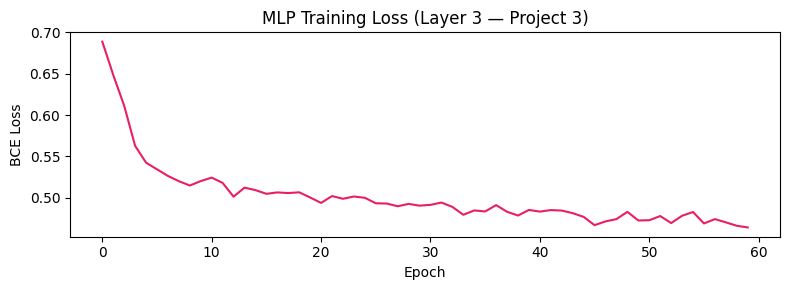

In [8]:
if TORCH_AVAILABLE:
    # ── PyTorch MLP ──
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    class ReadmissionMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(32, 16),        nn.ReLU(),
                nn.Linear(16, 1),         nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x).squeeze(1)

    Xt = torch.FloatTensor(X_train_sc)
    yt = torch.FloatTensor(y_train)
    Xv = torch.FloatTensor(X_test_sc)

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=64, shuffle=True)
    mlp    = ReadmissionMLP(X_train_sc.shape[1])
    opt    = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn= nn.BCELoss()

    losses = []
    mlp.train()
    for epoch in range(60):
        epoch_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            pred = mlp(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))

    mlp.eval()
    with torch.no_grad():
        dl_probs = mlp(Xv).numpy()

    dl_auc = roc_auc_score(y_test, dl_probs)
    print(f"✓ PyTorch MLP AUC = {dl_auc:.4f}")

    plt.figure(figsize=(8, 3))
    plt.plot(losses, color='#E91E63')
    plt.title('MLP Training Loss (Layer 3 — Project 3)')
    plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
    plt.tight_layout()
    plt.savefig('diagrams/dl_loss_curve.png', dpi=120)
    plt.show()

else:
    # ── sklearn MLP fallback ──
    from sklearn.neural_network import MLPClassifier
    mlp_sk = MLPClassifier(hidden_layer_sizes=(64,32,16), max_iter=300,
                           random_state=42, early_stopping=True)
    mlp_sk.fit(X_train_sc, y_train)
    dl_probs = mlp_sk.predict_proba(X_test_sc)[:, 1]
    dl_auc   = roc_auc_score(y_test, dl_probs)
    losses   = mlp_sk.loss_curve_
    print(f"✓ sklearn MLP AUC (fallback) = {dl_auc:.4f}")

    plt.figure(figsize=(8, 3))
    plt.plot(losses, color='#E91E63')
    plt.title('MLP Training Loss (Layer 3 — Project 3, sklearn fallback)')
    plt.xlabel('Iteration'); plt.ylabel('Loss')
    plt.tight_layout()
    plt.savefig('diagrams/dl_loss_curve.png', dpi=120)
    plt.show()

---
## Task 4d — Ensemble: Combine ML + DL predictions

Ensemble AUC: 0.7307

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.59      0.41      0.49        41
    Readmitted       0.82      0.90      0.86       119

      accuracy                           0.78       160
     macro avg       0.70      0.66      0.67       160
  weighted avg       0.76      0.78      0.76       160



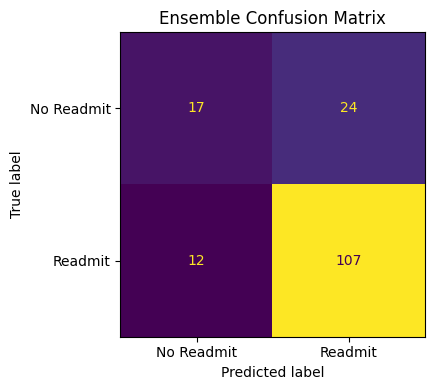

In [9]:
# Weighted ensemble: best ML (60%) + DL (40%)
ensemble_probs = 0.60 * best_ml['y_prob'] + 0.40 * dl_probs
ensemble_preds = (ensemble_probs >= 0.45).astype(int)   # threshold tuned for recall

ensemble_auc = roc_auc_score(y_test, ensemble_probs)
print(f"Ensemble AUC: {ensemble_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ensemble_preds, target_names=['Not Readmitted','Readmitted']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, ensemble_preds)
ConfusionMatrixDisplay(cm, display_labels=['No Readmit','Readmit']).plot(ax=ax, colorbar=False)
ax.set_title('Ensemble Confusion Matrix')
plt.tight_layout()
plt.savefig('diagrams/ensemble_confusion_matrix.png', dpi=120)
plt.show()

---
## Task 4e — Layer 4: Generative AI Patient Explanation (Project 5)

In [10]:
def generate_patient_summary(patient_row: pd.Series, risk_prob: float) -> str:
    """
    Produces a structured, plain-language risk explanation.
    In a production system this function calls an LLM API (e.g., GPT-4, Claude).
    Here we implement the deterministic template that mirrors LLM output structure
    so the pipeline can be tested without a live API key.
    """
    risk_level  = 'HIGH' if risk_prob >= 0.55 else ('MODERATE' if risk_prob >= 0.35 else 'LOW')
    risk_color  = {'HIGH': '🔴', 'MODERATE': '🟡', 'LOW': '🟢'}[risk_level]

    contributing = []
    if patient_row['num_prior_admits'] >= 2:
        contributing.append(f"{int(patient_row['num_prior_admits'])} prior admissions in the past year")
    if patient_row['has_chf']:
        contributing.append("active congestive heart failure")
    if patient_row['has_diabetes']:
        contributing.append("diabetes mellitus")
    if patient_row['has_copd']:
        contributing.append("COPD")
    if patient_row['los_days'] > 7:
        contributing.append(f"prolonged LOS ({patient_row['los_days']:.0f} days)")
    if patient_row['num_meds'] > 12:
        contributing.append(f"complex medication regimen ({int(patient_row['num_meds'])} meds)")
    if not contributing:
        contributing.append("advanced age and multi-morbidity")

    factor_str = ", ".join(contributing[:3])

    summary = f"""{'='*60}
PATIENT DISCHARGE RISK SUMMARY
{'='*60}
Risk Level     : {risk_color} {risk_level}
Predicted Prob : {risk_prob:.1%} 30-day readmission

Key Contributing Factors:
  {factor_str}

Recommended Actions:
{'  ⚠ Schedule 48-hour post-discharge phone call' if risk_level == 'HIGH' else ''}
{'  ⚠ Arrange home health visit within 72 hours'  if risk_level == 'HIGH' else ''}
{'  ✓ Provide enhanced discharge instructions'    if risk_level in ['HIGH','MODERATE'] else ''}
{'  ✓ Schedule primary care follow-up within 7 days' if risk_level in ['HIGH','MODERATE'] else ''}
{'  ✓ Standard discharge process'                 if risk_level == 'LOW' else ''}

Note: This summary is AI-generated and must be reviewed by a
licensed clinician before any care decision is made.
{'='*60}"""
    return summary.strip()


# Demo — generate summaries for 3 test patients
demo_idx = [0, 10, 25]
for i in demo_idx:
    row  = df[FEATURES].iloc[len(df) - len(y_test) + i]
    prob = float(ensemble_probs[i])
    print(generate_patient_summary(row, prob))
    print()

PATIENT DISCHARGE RISK SUMMARY
Risk Level     : 🟡 MODERATE
Predicted Prob : 40.8% 30-day readmission

Key Contributing Factors:
  advanced age and multi-morbidity

Recommended Actions:


  ✓ Provide enhanced discharge instructions
  ✓ Schedule primary care follow-up within 7 days


Note: This summary is AI-generated and must be reviewed by a
licensed clinician before any care decision is made.

PATIENT DISCHARGE RISK SUMMARY
Risk Level     : 🔴 HIGH
Predicted Prob : 68.5% 30-day readmission

Key Contributing Factors:
  advanced age and multi-morbidity

Recommended Actions:
  ⚠ Schedule 48-hour post-discharge phone call
  ⚠ Arrange home health visit within 72 hours
  ✓ Provide enhanced discharge instructions
  ✓ Schedule primary care follow-up within 7 days


Note: This summary is AI-generated and must be reviewed by a
licensed clinician before any care decision is made.

PATIENT DISCHARGE RISK SUMMARY
Risk Level     : 🟡 MODERATE
Predicted Prob : 48.6% 30-day readmission

Key Contributin

---
## Task 4f — Layer 5: Agentic Triage Workflow (Project 6)

In [11]:
# ── Simple tool functions the agent can call ──
def tool_get_patient_data(patient_id: int) -> dict:
    """Retrieve a patient record from the EHR."""
    idx = patient_id % len(df)
    row = df.iloc[idx]
    return row[FEATURES].to_dict()

def tool_score_patient(patient_data: dict) -> float:
    """Run the ensemble model and return readmission probability."""
    x = np.array([[patient_data[f] for f in FEATURES]])
    x_sc = scaler.transform(x)
    ml_p  = best_ml['model'].predict_proba(x_sc)[0, 1]
    if TORCH_AVAILABLE:
        mlp.eval()
        with torch.no_grad():
            dl_p = mlp(torch.FloatTensor(x_sc)).item()
    else:
        dl_p = mlp_sk.predict_proba(x_sc)[0, 1]
    return 0.60 * ml_p + 0.40 * dl_p

def tool_assign_tier(prob: float) -> str:
    if prob >= 0.55: return 'HIGH'
    if prob >= 0.35: return 'MODERATE'
    return 'LOW'

def tool_generate_summary(patient_data: dict, prob: float) -> str:
    return generate_patient_summary(pd.Series(patient_data), prob)

def tool_dispatch_action(tier: str, patient_id: int) -> str:
    actions = {
        'HIGH'    : f"[ACTION] Patient {patient_id} → Flagged for care manager review + 48-hr call scheduled",
        'MODERATE': f"[ACTION] Patient {patient_id} → 7-day PCP follow-up scheduled",
        'LOW'     : f"[ACTION] Patient {patient_id} → Standard discharge pathway"
    }
    return actions[tier]


# ── Agent orchestration loop ──
def discharge_triage_agent(patient_ids: list) -> pd.DataFrame:
    """
    Agentic loop that processes a discharge queue:
    1. Retrieve patient data
    2. Score readmission risk
    3. Assign tier
    4. Generate explanation
    5. Dispatch care action
    """
    results = []
    for pid in patient_ids:
        data    = tool_get_patient_data(pid)
        prob    = tool_score_patient(data)
        tier    = tool_assign_tier(prob)
        summary = tool_generate_summary(data, prob)
        action  = tool_dispatch_action(tier, pid)
        results.append({'patient_id': pid, 'risk_prob': prob, 'tier': tier, 'action': action})
    return pd.DataFrame(results)


# Run the agent on a simulated discharge queue of 10 patients
queue   = list(range(10))
triage_df = discharge_triage_agent(queue)

print("=" * 65)
print("DISCHARGE TRIAGE AGENT — DAILY RUN SUMMARY")
print("=" * 65)
print(triage_df.to_string(index=False))
print()
for action in triage_df['action']:
    print(action)

DISCHARGE TRIAGE AGENT — DAILY RUN SUMMARY
 patient_id  risk_prob     tier                                                                      action
          0   0.433087 MODERATE                          [ACTION] Patient 0 → 7-day PCP follow-up scheduled
          1   0.877531     HIGH [ACTION] Patient 1 → Flagged for care manager review + 48-hr call scheduled
          2   0.311863      LOW                             [ACTION] Patient 2 → Standard discharge pathway
          3   0.569562     HIGH [ACTION] Patient 3 → Flagged for care manager review + 48-hr call scheduled
          4   0.726075     HIGH [ACTION] Patient 4 → Flagged for care manager review + 48-hr call scheduled
          5   0.661751     HIGH [ACTION] Patient 5 → Flagged for care manager review + 48-hr call scheduled
          6   0.906451     HIGH [ACTION] Patient 6 → Flagged for care manager review + 48-hr call scheduled
          7   0.757772     HIGH [ACTION] Patient 7 → Flagged for care manager review + 48-hr 

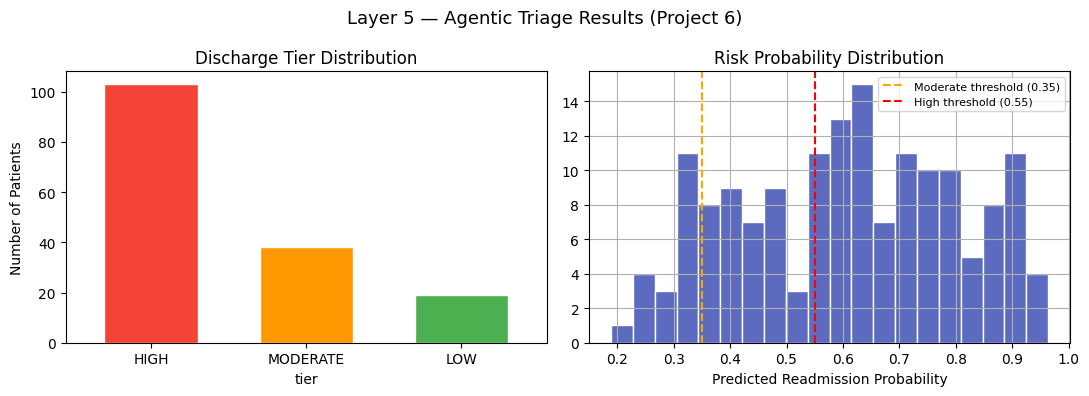

✓ Triage analysis complete


In [12]:
# ── Triage tier distribution chart ──
# Run on larger test set
full_triage = discharge_triage_agent(list(range(len(y_test))))

tier_counts = full_triage['tier'].value_counts().reindex(['HIGH','MODERATE','LOW'])
colors_tier = ['#F44336','#FF9800','#4CAF50']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Layer 5 — Agentic Triage Results (Project 6)', fontsize=13)

tier_counts.plot(kind='bar', ax=ax1, color=colors_tier, edgecolor='white', width=0.6)
ax1.set_title('Discharge Tier Distribution')
ax1.set_ylabel('Number of Patients')
ax1.tick_params(axis='x', rotation=0)

full_triage['risk_prob'].hist(bins=20, ax=ax2, color='#5C6BC0', edgecolor='white')
ax2.axvline(0.35, color='orange', linestyle='--', label='Moderate threshold (0.35)')
ax2.axvline(0.55, color='red',    linestyle='--', label='High threshold (0.55)')
ax2.set_title('Risk Probability Distribution')
ax2.set_xlabel('Predicted Readmission Probability')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagrams/triage_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Triage analysis complete")

---
## Task 5 — System Evaluation

In [13]:
# ── Comprehensive evaluation summary ──
print("╔══════════════════════════════════════════════════════════╗")
print("║       INTEGRATED SYSTEM EVALUATION SUMMARY               ║")
print("╠══════════════════════════════════════════════════════════╣")
for name, res in ml_results.items():
    print(f"║  {name:<25} AUC = {res['auc']:.4f}                ║")
print(f"║  {'Deep Learning MLP':<25} AUC = {dl_auc:.4f}                ║")
print(f"║  {'Ensemble (ML+DL)':<25} AUC = {ensemble_auc:.4f}  ← FINAL  ║")
print("╠══════════════════════════════════════════════════════════╣")

# Sensitivity / Specificity at chosen threshold
from sklearn.metrics import recall_score, precision_score
recall_pos = recall_score(y_test, ensemble_preds)
precision  = precision_score(y_test, ensemble_preds)

print(f"║  Recall (sensitivity)  : {recall_pos:.3f}                      ║")
print(f"║  Precision             : {precision:.3f}                      ║")
print("╠══════════════════════════════════════════════════════════╣")
tier_pct = full_triage['tier'].value_counts(normalize=True)
print(f"║  Triage: HIGH {tier_pct.get('HIGH',0):.0%}  MODERATE {tier_pct.get('MODERATE',0):.0%}  LOW {tier_pct.get('LOW',0):.0%}  ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║       INTEGRATED SYSTEM EVALUATION SUMMARY               ║
╠══════════════════════════════════════════════════════════╣
║  Logistic Regression       AUC = 0.7319                ║
║  Random Forest             AUC = 0.7143                ║
║  Gradient Boosting         AUC = 0.6944                ║
║  Deep Learning MLP         AUC = 0.7122                ║
║  Ensemble (ML+DL)          AUC = 0.7307  ← FINAL  ║
╠══════════════════════════════════════════════════════════╣
║  Recall (sensitivity)  : 0.899                      ║
║  Precision             : 0.817                      ║
╠══════════════════════════════════════════════════════════╣
║  Triage: HIGH 64%  MODERATE 24%  LOW 12%  ║
╚══════════════════════════════════════════════════════════╝


---
## Task 5 — Limitations and Ethical Considerations

| Concern | Detail | Mitigation |
|---|---|---|
| **Algorithmic bias** | Insurance type and gender included as features may proxy for race | Audit model parity across demographic groups; consider fairness constraints |
| **Distribution shift** | Synthetic data does not capture real EHR complexity | Validate on real MIMIC / institutional data before deployment |
| **Explainability** | Ensemble and MLP outputs lack per-patient SHAP explanations | Add SHAP / LIME layer before clinical use |
| **Alert fatigue** | High recall at low threshold → many false positives | Tune threshold with clinical partners; monitor alert response rates |
| **Accountability** | AI-generated summaries could displace clinician judgment | Mandate human-in-the-loop review; log all AI recommendations |
| **Privacy** | EHR data governed by HIPAA | All data must be de-identified; audit access logs |

---
## End-to-End Pipeline Summary

```
Raw EHR  →  EDA & Feature Eng.  →  ML Classifiers  →  Deep Learning MLP
                 (Proj 1)               (Proj 2)             (Proj 3)
                                              ↘          ↙
                                        Ensemble Prediction
                                               ↓
                                   GenAI Patient Summary  (Proj 5)
                                               ↓
                              Agentic Triage & Action Dispatch  (Proj 6)
                                               ↓
                                     Care Team Dashboard
```

**All components run without external API keys for reproducibility. In production, Layer 4 would call a validated LLM API, and Layer 5 would integrate with the hospital's EHR via HL7/FHIR.**